In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = df_raw.copy()

**1. Basic dataset check**

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**2. Data types + missing values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**3. Check TotalCharges**

In [ ]:
print("Blank TotalCharges:",
      (df['TotalCharges'].str.strip() == '').sum())

Blank TotalCharges: 11


In [ ]:
df[df['TotalCharges'].str.strip() == ''][[
    'customerID',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**4. Clean TotalCharges**

In [ ]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
print("Missing TotalCharges:",
      df['TotalCharges'].isnull().sum())

Missing TotalCharges: 11


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
print("Missing TotalCharges:",
      df['TotalCharges'].isnull().sum())

print("Data type:",
      df['TotalCharges'].dtype)

Missing TotalCharges: 0
Data type: float64


**5. Check target variable - Churn**

In [ ]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**6. Numerical summary**


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**7. Separate ML dataset**

In [ ]:
df_ml = df.drop(columns=['customerID'])

In [ ]:
print(df_ml.shape)

(7043, 20)


**8. Exploratory Data Analysis (EDA)**

**8.1 Churn Distribution**

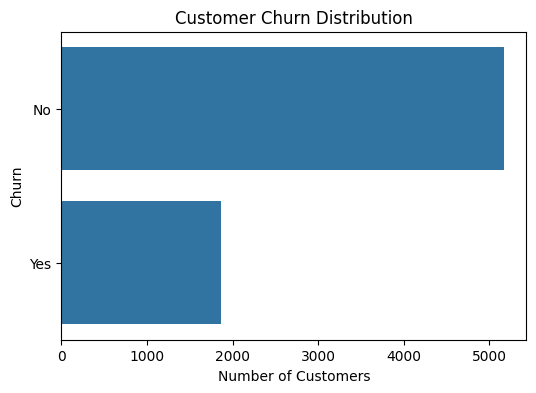

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, y='Churn')

plt.title('Customer Churn Distribution')
plt.ylabel('Churn')
plt.xlabel('Number of Customers')

plt.show()

**8.2 Contract Type vs Churn**

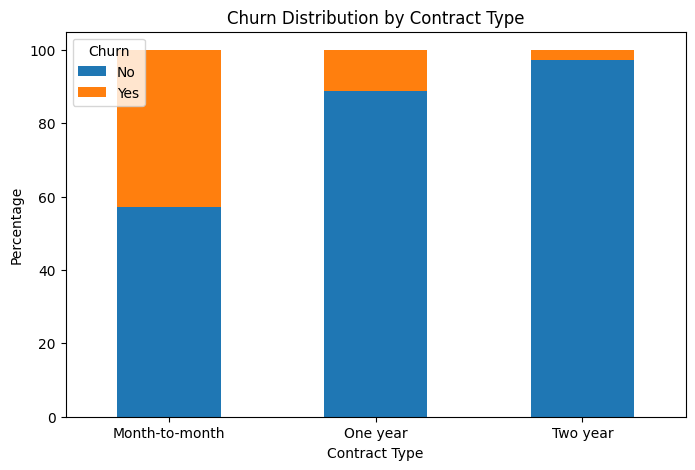

In [23]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**8.3 Monthly Charges vs Churn**

In [ ]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


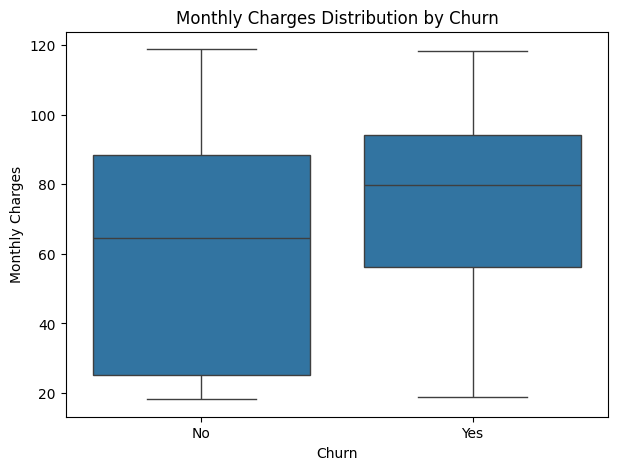

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

**8.4 Internet Service vs Churn**

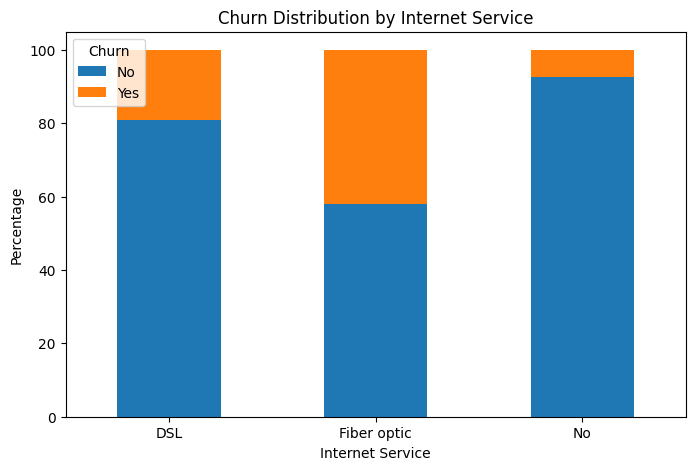

In [27]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**8.5 Payment Method vs Churn**

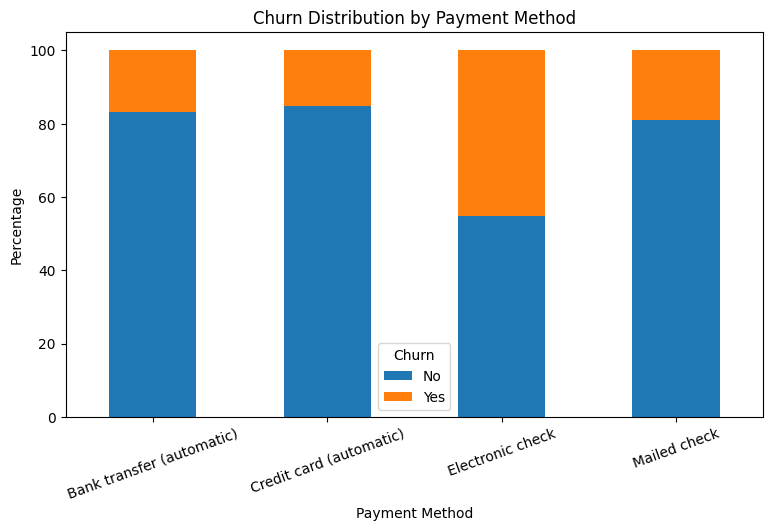

In [8]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.show()

**8.6 Tenure vs Churn**

In [ ]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


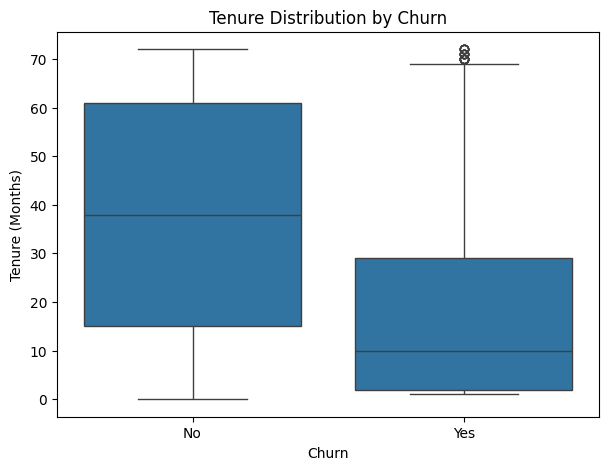

In [9]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

**8.7 Senior Citizen vs Churn**

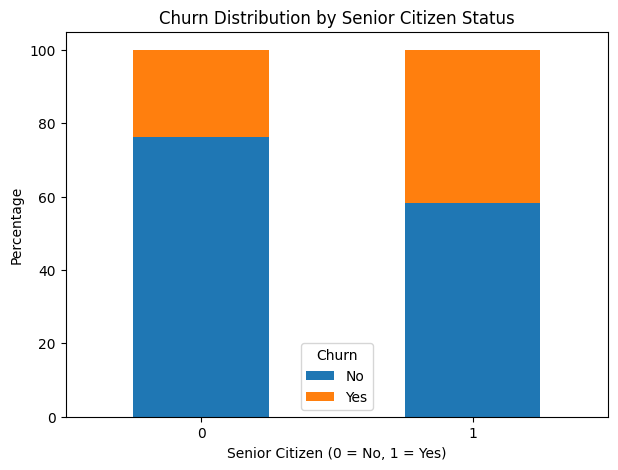

In [14]:
senior_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

senior_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title('Churn Distribution by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [16]:
print(df['TotalCharges'].dtype)

object


**Error Handling(Total Charges)**

In [17]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [18]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [19]:
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

11
float64


In [20]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [21]:
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64



**8.8 Total Charges vs Churn**

In [22]:
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


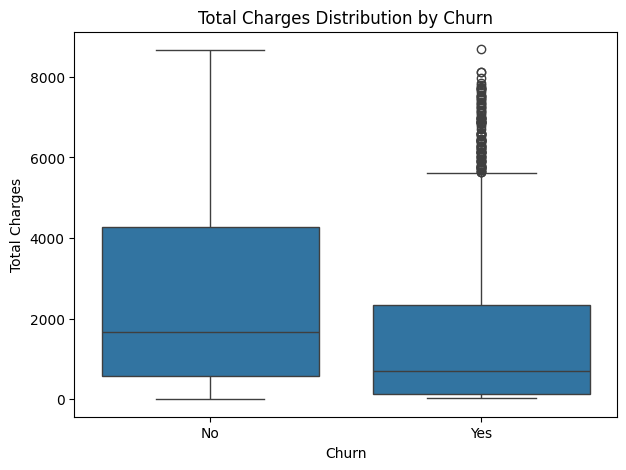

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title('Total Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

**8.9 Tenure vs Total Charges**

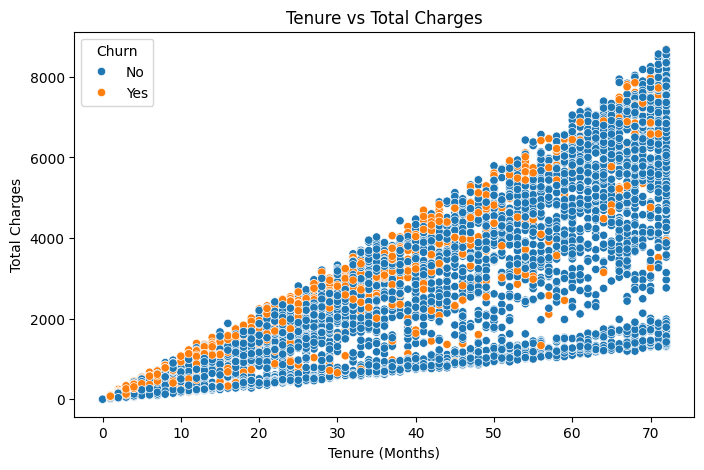

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='TotalCharges',
    hue='Churn'
)

plt.title('Tenure vs Total Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges')

plt.show()